In [120]:
import pandas as pd
from scipy.io import arff
from patsy import dmatrices
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split,StratifiedKFold, KFold, cross_val_predict, LeaveOneOut
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA

In [163]:

# Load ARFF file
data = arff.loadarff('blood.arff')

df = pd.DataFrame(data[0])


for col in df.select_dtypes([object]).columns:
    df[col] = df[col].str.decode("utf-8")
    
df.columns = ['Recency', 'Frequency', 'Volume', 'Time', 'Class']



In [164]:
print(df)
classes = df['Class'].value_counts()

     Recency  Frequency   Volume  Time Class
0        2.0       50.0  12500.0  98.0     2
1        0.0       13.0   3250.0  28.0     2
2        1.0       16.0   4000.0  35.0     2
3        2.0       20.0   5000.0  45.0     2
4        1.0       24.0   6000.0  77.0     1
..       ...        ...      ...   ...   ...
743     23.0        2.0    500.0  38.0     1
744     21.0        2.0    500.0  52.0     1
745     23.0        3.0    750.0  62.0     1
746     39.0        1.0    250.0  39.0     1
747     72.0        1.0    250.0  72.0     1

[748 rows x 5 columns]


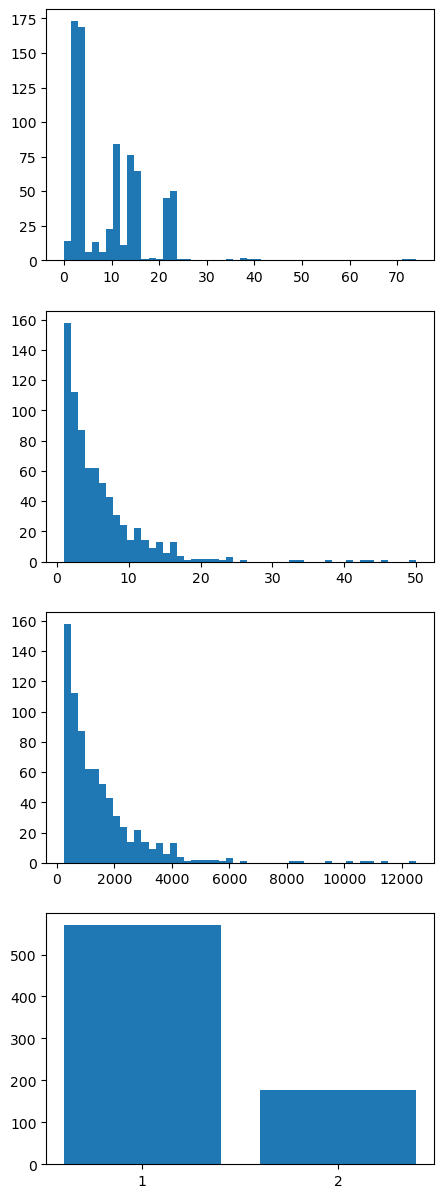

([<matplotlib.patches.Wedge at 0x7d13a4bed1d0>,
 [Text(-0.7478675273539199, -0.8066561606592577, '1'),
  Text(0.747867456833793, 0.8066562260399128, '2')],
 [Text(-0.40792774219304717, -0.4399942694505042, '76.2%'),
  Text(0.4079277037275234, 0.43999430511267973, '23.8%')])

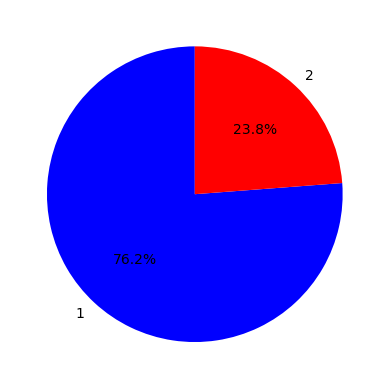

In [51]:
plt.figure(figsize=(5,15))
plt.subplot(4,1,1)
plt.hist(df['V1'], bins=50)
plt.subplot(4,1,2)
plt.hist(df['V2'], bins=50)
plt.subplot(4,1,3)
plt.hist(df['V3'],  bins=50)
plt.subplot(4,1,4)
plt.bar(classes.index, classes.values)
plt.show()
plt.pie(classes.values, labels=['1', '2'],
            colors=['blue', 'red'], autopct='%1.1f%%', startangle=90)


In [39]:
ha_null = df.isnull().any()  
ha_null

V1       False
V2       False
V3       False
V4       False
Class    False
dtype: bool

In [40]:
print(df.nunique())

V1       31
V2       33
V3       33
V4       78
Class     2
dtype: int64


Agora que observei as distribuições e percebi que a baseline é 76.2%. A seguir iniciarei a montar modelos e buscar a melhor acurácia

In [109]:
results = []

In [100]:


#Com isso teremos X e y para aplicar os modelos
y = df['Class']
X = df.drop(columns=['Class'])



In [111]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.25, random_state=2,  stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

modelo = LogisticRegression(max_iter=500)
modelo.fit(X_train_scaled, y_train)

pred_20 = modelo.predict(X_test_scaled)


print(f"Acurácia: {accuracy_score(y_test, pred_20):.5f}")
print("\nRelatório de Classificação:\n", classification_report(y_test, pred_20))

# Mostra o número exato de iterações realizadas
print(f"O modelo convergiu em {modelo.n_iter_[0]} iterações.")

results.append(accuracy_score(y_test, pred_20))


Acurácia: 0.79144

Relatório de Classificação:
               precision    recall  f1-score   support

           1       0.79      0.99      0.88       143
           2       0.78      0.16      0.26        44

    accuracy                           0.79       187
   macro avg       0.78      0.57      0.57       187
weighted avg       0.79      0.79      0.73       187

O modelo convergiu em 7 iterações.


In [128]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.25, random_state=2,  stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

modelo = LDA()
modelo.fit(X_train_scaled, y_train)

pred_20 = modelo.predict(X_test_scaled)


print(f"Acurácia: {accuracy_score(y_test, pred_20):.5f}")
print("\nRelatório de Classificação:\n", classification_report(y_test, pred_20))

# Mostra o número exato de iterações realizadas
#print(f"O modelo convergiu em {modelo.n_iter_[0]} iterações.")

results.append(accuracy_score(y_test, pred_20))


Acurácia: 0.79144

Relatório de Classificação:
               precision    recall  f1-score   support

           1       0.79      0.99      0.88       143
           2       0.86      0.14      0.24        44

    accuracy                           0.79       187
   macro avg       0.82      0.56      0.56       187
weighted avg       0.80      0.79      0.73       187



In [113]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('modelo', LogisticRegression(max_iter=1000))
])


# K-fold Cross Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
pred_kfold = cross_val_predict(pipeline, X, y, cv=kf)


prob_kfold = cross_val_predict(pipeline, X, y, cv=kf, method='predict_proba')[:, 1]
print(f"AUC-ROC (K-Fold): {roc_auc_score(y, prob_kfold):.4f}")

print("KFold")
print(classification_report(y, pred_kfold))
print("Accuracy:", accuracy_score(y, pred_kfold))
results.append(accuracy_score(y, pred_kfold))

# Leave One Out Cross Validation (LOOCV)
loo = LeaveOneOut()
pred_loocv = cross_val_predict(pipeline, X, y, cv=loo)

print("\nLOOCV")
print(classification_report(y, pred_loocv))
print("Accuracy:", accuracy_score(y, pred_loocv))
results.append(accuracy_score(y, pred_loocv))

AUC-ROC (K-Fold): 0.7394
KFold
              precision    recall  f1-score   support

           1       0.78      0.98      0.87       570
           2       0.61      0.12      0.21       178

    accuracy                           0.77       748
   macro avg       0.70      0.55      0.54       748
weighted avg       0.74      0.77      0.71       748

Accuracy: 0.7727272727272727

LOOCV
              precision    recall  f1-score   support

           1       0.78      0.97      0.87       570
           2       0.58      0.12      0.20       178

    accuracy                           0.77       748
   macro avg       0.68      0.55      0.53       748
weighted avg       0.73      0.77      0.71       748

Accuracy: 0.7700534759358288


In [165]:
results

[0.7914438502673797,
 0.7727272727272727,
 0.7700534759358288,
 0.7767379679144385,
 0.7713903743315508,
 0.7914438502673797,
 np.float64(0.7700534759358288)]

([<matplotlib.axis.XTick at 0x7d13a172ce10>,
 [Text(0, 0, 'LR-25%'),
  Text(1, 0, 'LR-K-Fold'),
  Text(2, 0, 'LR-LOOCV'),
  Text(3, 0, 'LDA-K-Fold'),
  Text(4, 0, 'LDA-LOOCV'),
  Text(5, 0, 'LDA-25%'),
  Text(6, 0, 'NB-25%')])

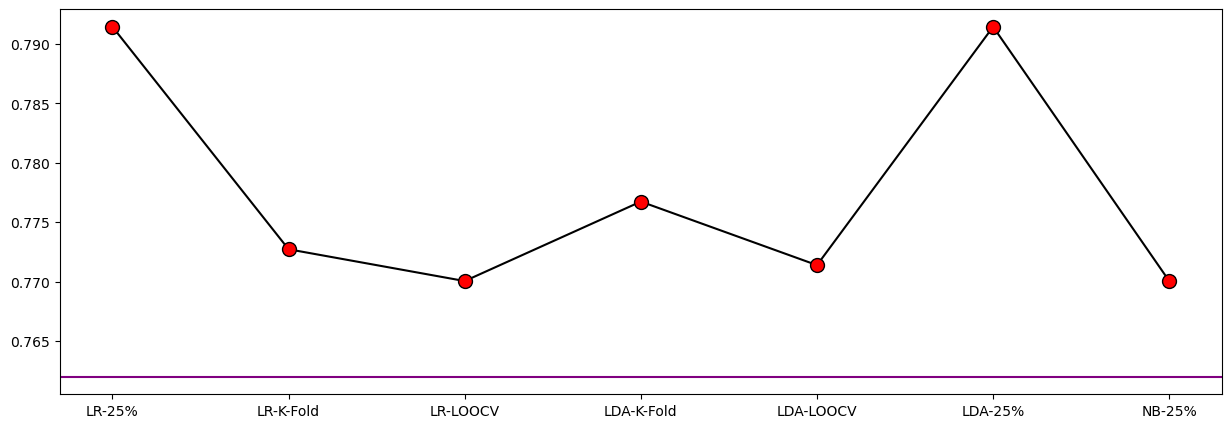

In [156]:
import matplotlib.pyplot as plt
metodos = ['LR-25%','LR-K-Fold','LR-LOOCV', 'LDA-K-Fold', 'LDA-LOOCV', 'LDA-25%', 'NB-25%']

plt.figure(figsize=(15,5))
plt.plot(results, marker = 'o', c='black', mfc='red', ms=10)
plt.axhline(y=0.762, color='purple', linestyle='-')
plt.xticks(range(len(metodos)), metodos)

In [115]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('modelo', LDA())
])


# K-fold Cross Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
pred_kfold_LDA = cross_val_predict(pipeline, X, y, cv=kf)


prob_kfold = cross_val_predict(pipeline, X, y, cv=kf, method='predict_proba')[:, 1]
print(f"AUC-ROC (K-Fold): {roc_auc_score(y, prob_kfold):.4f}")

print("KFold")
print(classification_report(y, pred_kfold))
print("Accuracy:", accuracy_score(y, pred_kfold))
results.append(accuracy_score(y, pred_kfold))

# Leave One Out Cross Validation (LOOCV)
loo = LeaveOneOut()
pred_loocv_LDA = cross_val_predict(pipeline, X, y, cv=loo)

print("\nLOOCV")
print(classification_report(y, pred_loocv))
print("Accuracy:", accuracy_score(y, pred_loocv))
results.append(accuracy_score(y, pred_loocv))

AUC-ROC (K-Fold): 0.7380
KFold
              precision    recall  f1-score   support

           1       0.78      0.98      0.87       570
           2       0.68      0.12      0.20       178

    accuracy                           0.78       748
   macro avg       0.73      0.55      0.54       748
weighted avg       0.76      0.78      0.71       748

Accuracy: 0.7767379679144385

LOOCV
              precision    recall  f1-score   support

           1       0.78      0.98      0.87       570
           2       0.61      0.11      0.18       178

    accuracy                           0.77       748
   macro avg       0.70      0.54      0.52       748
weighted avg       0.74      0.77      0.70       748

Accuracy: 0.7713903743315508


In [101]:
pipeline.fit(X, y)
print(pipeline.named_steps['modelo'].classes_)

['1' '2']


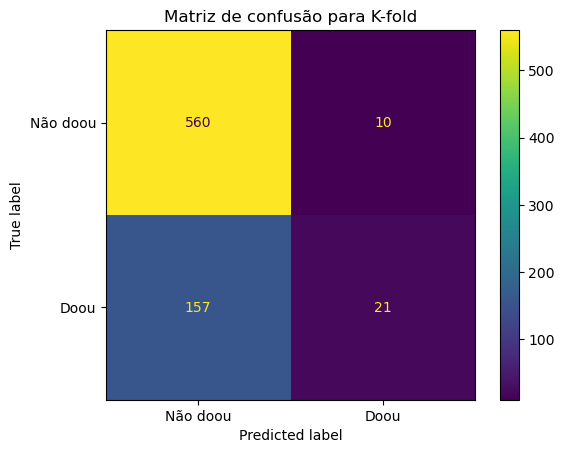

In [135]:
labels = ['Não doou', 'Doou']
cm = confusion_matrix(y, pred_kfold)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot()
plt.title("Matriz de confusão para K-fold")
plt.show()

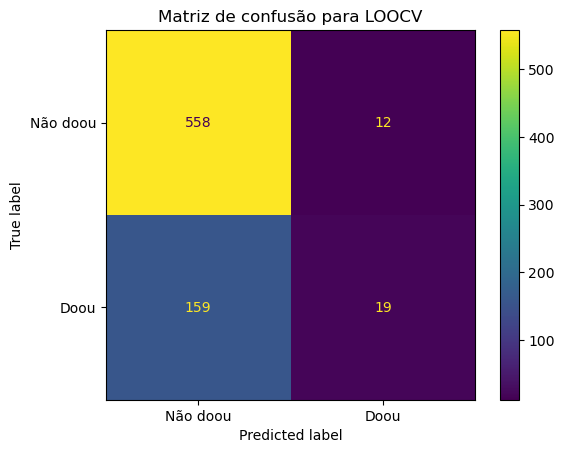

In [136]:
cm = confusion_matrix(y, pred_loocv)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot()
plt.title("Matriz de confusão para LOOCV")
plt.show()

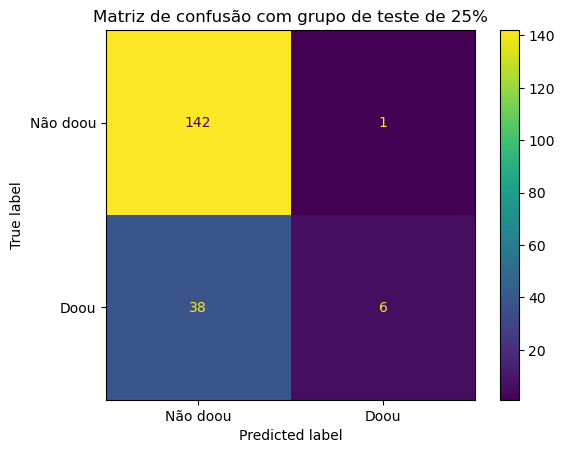

In [137]:

ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_20,
    display_labels=labels

)
plt.title('Matriz de confusão com grupo de teste de 25%')
plt.show()

In [139]:
X.corr()

,V1,V2,V3,V4
V1,1.000000,-0.182745,-0.182745,0.160618
V2,-0.182745,1.000000,1.000000,0.634940
V3,-0.182745,1.000000,1.000000,0.634940
V4,0.160618,0.634940,0.634940,1.000000


Como V2 e V3 apresentam correlação QDA não é um bom método para esse dataset


In [150]:
NB_class = NB()
NB_class.fit(X_train, y_train)
y_test_labels = NB_class.predict(X_test)
y_test_prob = NB_class.predict_proba(X_test)
print(np.mean(y_test == y_test_labels))
#print(np.mean(y_test == y_test_prob))

0.7700534759358288


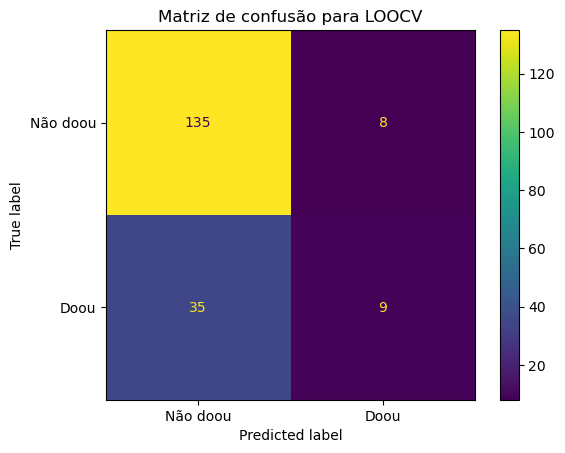

In [152]:
cm = confusion_matrix(y_test, y_test_labels)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot()
plt.title("Matriz de confusão para LOOCV")
plt.show()

In [142]:
from sklearn.naive_bayes import GaussianNB as NB

In [154]:
results.append(np.mean(y_test == y_test_labels))
